In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

COL_AXIS = 1

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def step(x):
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            if x[i][j] > 0:
                x[i][j] = 1
            else:
                x[i][j] = 0
    return x

################################################

class Perceptron():

    def __init__(self, layers, activation = "sigmoid"):
        self.activation = activation
        self.layers = layers
        self.l = len(layers)
        a, b = 0.001, 0.2
        self.w = [np.random.uniform(a,b,(layers[i]+1,layers[i+1])) for i in range(0,len(layers)-1)] 
        self.w.insert(0,[])

        
    def addBias(self, xh):
        return np.concatenate( ( xh, np.ones((1,1)) ) ,axis=COL_AXIS) #adding col for threshold 
        
      
    def subBias(self, v):
        return np.delete(v, v.shape[1]-1, axis=COL_AXIS)

    
    def activation_function(self, yb):
        if self.activation == "sigmoid":
            yb = sigmoid(yb)
        elif self.activation == "step":
            yb = step(yb)
        return yb
        
        
    def activate(self, xh):    #xh es un vector de dimension (#cols,)
        y  = [np.zeros(self.layers[i]).reshape((1,self.layers[i])) for i in range(0,len(self.layers))] # y debe tener tamaño #layers
        yb = xh.reshape((1,len(xh)))
        
        for k in range(1,self.l):
            y[k-1] = self.addBias(yb)
            yb = np.dot(y[k-1],self.w[k])
            yb = self.activation_function(yb)
            
        y[-1] = np.array(yb)
        return y


    def correction(self,nu,y,zh):
        e = zh - y[self.l-1]  #arrays de dimension (3,)
        dw = [np.zeros((self.layers[i]+1,self.layers[i+1])) for i in range(0,len(self.layers)-1)]
        dw.insert(0,[])#dW con tamaño #layers
        d =  [0 for i in range(self.l)]
        ones = np.ones(y[-1].shape)
        dy = ones - (y[-1]*y[-1]) #debe ser producto posicion a posicion
        d[self.l-1] = e*dy

        for k in range(self.l-1, 0, -1):         
            dw[k] = nu * np.matmul(y[k-1].T, d[k])
            e = np.matmul(d[k],self.w[k].T)  #tuve que quitar el .T... nuse
            dy = np.ones(y[k-1].shape) - (y[k-1]*y[k-1])
            d[k-1] = self.subBias(e*dy)
        return dw
        
        
    def predict(self, x):
        x = np.append(x,[-1])
        return self.activate(x)
    
    
    def train(self, x, z, epochs=100, nu=0.01, epsilon = 0.001):
        p = x.shape[0]
        t=1
        err = []
        while t < epochs:
            e = 0
            for h in range(p):
                y = self.activate(x[h])
                dw = self.correction(nu,y,z[h])
                self.w += dw
            err.append(np.linalg.norm(y[-1]-z[h]))

            t+=1
        return err

## Example 1: XOR - AND gate

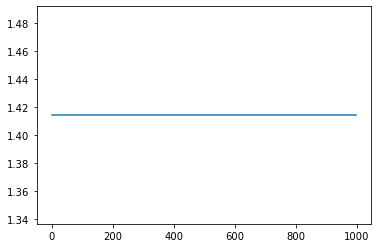

In [7]:
# n = 2 (input size)
# m = 2 (output size)
# p = 4 (#examples)
# L = 3 (#layers)

x = np.array([[1,1], [1,-1],[-1,1],[-1,-1]])
z = np.array([[1, 0], [0, 1], [0, 1], [0, 0]])
s = np.array([2,3,2])


#w debe ser una lista de tamaño 3
p = Perceptron(s, activation = "step")

err = p.train(x, z)

plt.plot(err)
#print(err)
#for i in range(len(x)):
#        print(str(p.predict(x[i])) + " =? " + str(z[i][0]) + str(z[i][1]) + str(z[i][2]))
